<img src=https://upload.wikimedia.org/wikipedia/commons/6/68/Logo_universidad_icesi.svg width=300>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sebastianb92/nlp-labs/blob/main/Session4/1-Text-classification-BERT.ipynb)


# Maestría en Inteligencia Artificial  
## Procesamiento de Lenguaje natural
### Sesión 4 - Práctica

---


**Integrantes:**  
- Johan Sebastian Bonilla  
- Edwin Gómez  

# Introducción

# Clasificación de textos - BERT

En este notebook se aborda el problema de clasificación de texto aplicado a la detección de contenido relacionado con el cambio climático. Para ello, se utiliza el dataset somosnlp/spa_climate_detection, el cual contiene textos en español etiquetados según su relación con esta temática.

El objetivo principal es desarrollar un modelo capaz de clasificar automáticamente textos en función de si están relacionados o no con el cambio climático. Para lograrlo, se emplea el modelo BERT, una arquitectura basada en transformers que permite capturar el contexto semántico del lenguaje de manera bidireccional, mejorando significativamente el rendimiento en tareas de procesamiento de lenguaje natural (NLP).

# 1. Configurar entorno

En esta sección se configuran las librerías y dependencias necesarias para el análisis de datos y procesamiento de lenguaje natural. Esto garantiza que el entorno esté listo para cargar, limpiar y analizar las reseñas.

In [33]:
import importlib.metadata
import warnings

warnings.filterwarnings('ignore')

installed_packages = [dist.metadata['Name'].lower() for dist in importlib.metadata.distributions()]
IN_COLAB = 'google-colab' in installed_packages

In [34]:
!pip install torchinfo #> /dev/null 2>&1
!pip install evaluate #> /dev/null 2>&1
!pip install transformers datasets

# 2. Recopilación de datos

Para el presente análisis se utilizará el conjunto de datos somosnlp/spa_climate_detection, disponible en Hugging Face, el cual contiene textos en español relacionados con la temática del cambio climático. Cada registro del dataset se encuentra etiquetado según si el contenido está o no asociado a este tema.

Este conjunto de datos permitirá evaluar el desempeño de modelos de procesamiento de lenguaje natural en una tarea de clasificación binaria de texto. En particular, se empleará el modelo BERT, el cual será ajustado (fine-tuning) sobre este corpus para aprovechar su capacidad de comprensión contextual del lenguaje.

De esta manera, se busca construir un modelo capaz de identificar automáticamente si un texto está relacionado con el cambio climático, evaluando su rendimiento mediante métricas estándar de clasificación.

In [35]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
dataset = load_dataset('somosnlp/spa_climate_detection', split='train')
dataset

Dataset({
    features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo'],
    num_rows: 2900
})

In [36]:
dataset[1]

{'question': 'Aunque la transformación de nuestros sistemas continuará más allá de 2021, nos hemos comprometido a mantenernos dentro del gasto orientativo de inversión en transformación de 1.400 millones de euros, lo que equivale a una media anual de 50 a 60 puntos básicos de capital de nivel 1 de fondos propios ordinarios (CET1) hasta 2021. Esperamos que la inversión en transformación después de 2021 sea menor.',
 'answer': 0,
 'dominio': 'cambio_climatico_reportes',
 'país_origen': 'global',
 'idioma': 'es_pe',
 'registro': 'culto',
 'tarea': 'clasificacion',
 'periodo': 'actual'}

# 3. Análisis Exploratorio

En esta sección se realiza un análisis exploratorio del conjunto de datos somosnlp/spa_climate_detection con el objetivo de comprender su estructura, distribución y características principales antes del proceso de modelado.

Inicialmente, se examina la cantidad total de registros, así como la distribución de las clases, con el fin de identificar posibles problemas de desbalanceo que puedan afectar el desempeño del modelo. Asimismo, se analizan características básicas de los textos, como la longitud de las secuencias, la frecuencia de palabras y la presencia de términos relevantes asociados al cambio climático.

Adicionalmente, se exploran ejemplos representativos de cada clase para entender mejor el tipo de contenido presente en el dataset y la complejidad de la tarea de clasificación. Este análisis permite identificar patrones, posibles ruidos en los datos y definir estrategias adecuadas de preprocesamiento y modelado.



## Estructura del Dataset

In [37]:
df = dataset.to_pandas()
df.head()

,question,answer,dominio,país_origen,idioma,registro,tarea,periodo
0,Programa de las Naciones Unidas para el Medio ...,1,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual
1,Aunque la transformación de nuestros sistemas ...,0,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual
2,Estrategia frente al cambio climático Los ries...,1,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual
3,Kelly Clarkson se mudó a la ciudad de Nueva Yo...,0,prensa_miscelaneo,USA,es_pe,medio,clasificacion,actual
4,La disminución de las inversiones a corto plaz...,0,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual


Revisamos los primero 5 registros del dataset para validar estructura y valores

## Análisis de Distribución

Distribución absoluta:
Counter({1: 1600, 0: 1300})

Distribución porcentual:
Clase 1: 1600 (55.17%)
Clase 0: 1300 (44.83%)


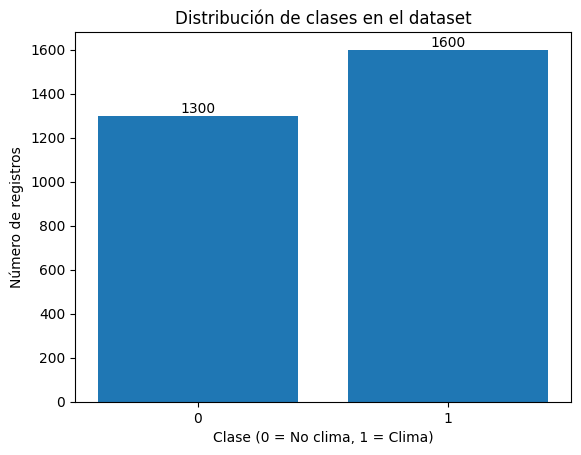

In [38]:
from collections import Counter
import matplotlib.pyplot as plt

labels = dataset["answer"]

# Contar clases
counter = Counter(labels)

# Mostrar conteo
print("Distribución absoluta:")
print(counter)

# Calcular proporciones
total = sum(counter.values())
print("\nDistribución porcentual:")
for cls, freq in counter.items():
    print(f"Clase {cls}: {freq} ({freq/total:.2%})")


plt.figure()
bars = plt.bar(counter.keys(), counter.values())

plt.xticks(list(counter.keys()))
plt.xlabel("Clase (0 = No clima, 1 = Clima)")
plt.ylabel("Número de registros")
plt.title("Distribución de clases en el dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height}', ha='center', va='bottom')

plt.show()

La distribución de clases en el dataset es relativamente equilibrada, con una ligera predominancia de la clase 1 (texto relacionado con cambio climático) (55.17%) frente a la clase 0 (texto no relacionado con cambio climático) (44.83%).

Aunque este desbalance no es extremo, sí puede influir en modelos menos adaptados a la tarea. Más adelante se observa que algunos modelos congelados tienden a favorecer la clase positiva, por lo que no basta con mirar únicamente la proporción global de ejemplos.


## Análisis del Texto

In [39]:
import numpy as np

text_lengths = [len(row['question'].split()) for row in dataset]

print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"{p}%: {np.percentile(text_lengths, p)}")

Texto más corto: 2
Texto más largo: 604
Longitud promedio: 114.15137931034482

Percentiles:
50%: 59.0
75%: 112.0
90%: 378.0
95%: 481.0
99%: 563.0199999999995


Los textos del dataset presentan una alta variabilidad en su longitud, con valores que van desde 2 hasta 604 palabras.

La longitud promedio es de aproximadamente 114 palabras, aunque la mediana (50%) se sitúa en 59, lo que indica una distribución sesgada con presencia de textos considerablemente más largos.

 Esto se confirma con los percentiles superiores, donde un pequeño porcentaje de textos alcanza longitudes significativamente mayores.

In [40]:
df['Palabras por clase'] = df['question'].str.split().apply(len)
df.groupby('answer')['Palabras por clase'].median()

answer
0    73.0
1    53.5
Name: Palabras por clase, dtype: float64

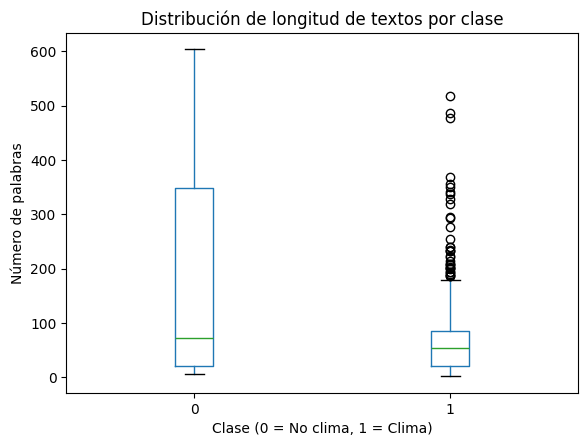

In [41]:
df.boxplot(column='Palabras por clase', by='answer', grid=False)
plt.title('Distribución de longitud de textos por clase')
plt.suptitle('')
plt.xlabel('Clase (0 = No clima, 1 = Clima)')
plt.ylabel('Número de palabras')
plt.show()

Se evidencia diferencias en la distribución de la longitud de los textos entre las clases. La clase 0 presenta una mayor dispersión y valores más extremos, indicando la presencia de textos considerablemente más largos, mientras que la clase 1 tiene una distribución más concentrada y homogénea.

Esto sugiere que la longitud del texto podría variar según la clase, aunque con cierto solapamiento entre ambas.

## Vocabulario

In [42]:
from collections import Counter

all_words = []
for text in dataset["question"]:
    all_words.extend(text.split())

vocab = Counter(all_words)
print("Tamaño del vocabulario:", len(vocab))

Tamaño del vocabulario: 41136


El dataset cuenta con 41136 palabras únicas lo que indica una alta diversidad léxica en los textos.

## Análisis de Ruido

In [43]:
df.sample(5)

,question,answer,dominio,país_origen,idioma,registro,tarea,periodo,Palabras por clase
141,Los activos de la actual cartera de Eni están ...,1,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual,34
1557,la policía nacional ha incorporado 300 vehícul...,0,prensa_miscelaneo,España,es_esp,medio,clasificacion,actual,220
485,"Peso Pluma en concierto, exhibición de disfrac...",0,prensa_miscelaneo,USA,es_pe,medio,clasificacion,actual,18
1712,El coste del préstamo está asociado a un objet...,1,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual,44
2250,Los organismos reguladores y legislativos extr...,1,cambio_climatico_reportes,global,es_pe,culto,clasificacion,actual,150


Podemos ver aleatoriamente algunos registros para rectificar la clasificación o valor de la etiqueta vs el texto

## Palabras más frecuentes y N-Gramas por clase

Analizamos las palabras y bigramas más frecuentes en cada polaridad, excluyendo stopwords, para identificar el vocabulario diferenciador entre comentarios de cada clase.

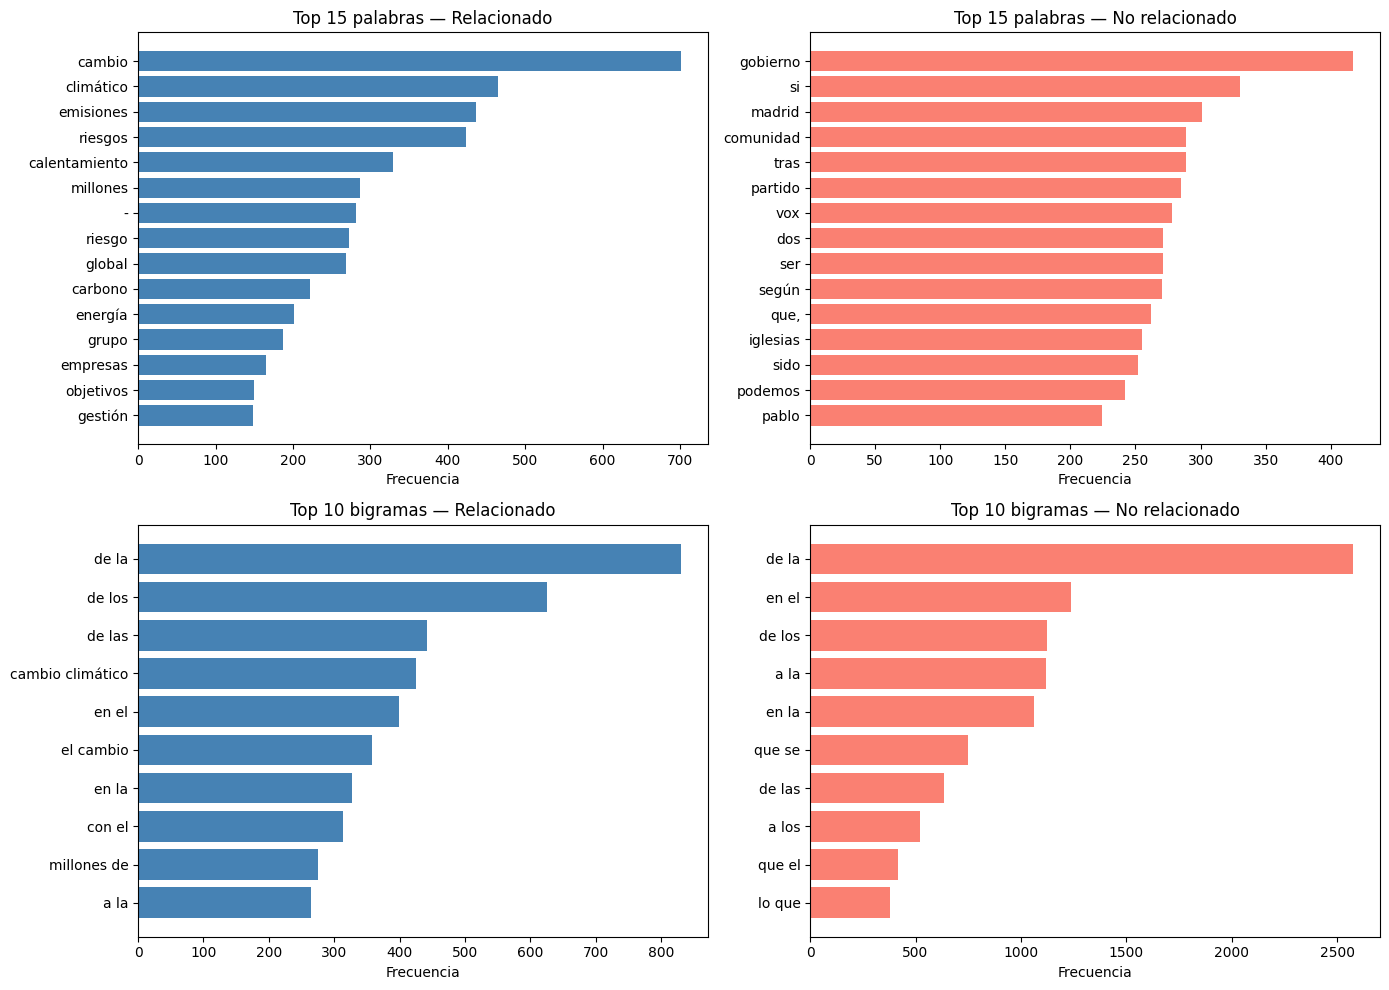

In [44]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("spanish"))
extra_stopwords = {
    'de', 'la', 'el', 'en', 'y', 'a', 'los', 'las', 'del', 'se', '(', ')',
    'que', 'con', 'un', 'una', 'es', 'no', 'lo', 'su', 'por', 'al', ',', '.', 'más', 'le', 'me', 'mi'
}
stop_words.update(extra_stopwords)

def top_words_by_class(ds, label, n=15, sw=None):
    words = []
    for row in ds:
        if row['answer'] == label:
            words.extend(row['question'].lower().split())
    if sw:
        words = [w for w in words if w not in sw]
    return Counter(words).most_common(n)

def get_bigrams(text):
    tokens = text.lower().split()
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens) - 1)]

top_pos = top_words_by_class(dataset, 1, sw=stop_words)
top_neg = top_words_by_class(dataset, 0, sw=stop_words)

bg_pos, bg_neg = Counter(), Counter()
for row in dataset:
    bgs = get_bigrams(row['question'])
    if row['answer'] == 1:
        bg_pos.update(bgs)
    else:
        bg_neg.update(bgs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, top, title, color in [
    (axes[0, 0], top_pos,                'Top 15 palabras — Relacionado', 'steelblue'),
    (axes[0, 1], top_neg,                'Top 15 palabras — No relacionado',  'salmon'),
    (axes[1, 0], bg_pos.most_common(10), 'Top 10 bigramas — Relacionado', 'steelblue'),
    (axes[1, 1], bg_neg.most_common(10), 'Top 10 bigramas — No relacionado',  'salmon'),
]:
    terms, freqs = zip(*top)
    ax.barh(list(terms)[::-1], list(freqs)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

- **Existe una clara diferenciación léxica entre clases**: en la clase relacionada con cambio climático predominan términos como *cambio, climático, emisiones, calentamiento y carbono*, lo que indica un vocabulario altamente específico del dominio.

- **Clase relacionada (1)** : se observan palabras directamente asociadas al contexto ambiental y científico, lo que sugiere que los textos contienen información más técnica o explícitamente vinculada al cambio climático.

- **Clase no relacionada (0)**: predominan términos más generales o contextuales como *gobierno, madrid, partido, vox*, lo que indica que muchos textos pertenecen a ámbitos políticos o sociales, pero no necesariamente al tema climático.

- **Baja superposición semántica relevante**: a diferencia de otros problemas (como sentimiento), aquí las clases parecen diferenciarse más por el tema que por el tono, lo que facilita la tarea de clasificación.

## Sobre los n-gramas (bigramas)

- Los bigramas más frecuentes (ej. de la, en el, de los) son principalmente estructuras gramaticales comunes del español, por lo que aportan poco valor discriminativo por sí solos.

- En la clase relacionada, aparecen combinaciones más informativas como *cambio climático, millones de, el cambio*, que refuerzan el contexto temático.

- En la clase no relacionada, los bigramas siguen siendo mayormente genéricos y estructurales, lo que confirma la menor presencia de expresiones específicas del dominio climático.

- Para mejorar la capacidad discriminativa, sería útil enfocarse en n-gramas más semánticos o aplicar técnicas que capturen mejor el contexto, como embeddings generados por BERT.


# 4. Tokenizador

En esta etapa se realiza el proceso de tokenización del texto utilizando el tokenizador preentrenado asociado al modelo BERT. En particular, se emplea el tokenizador correspondiente al modelo dccuchile/bert-base-spanish-wwm-cased, disponible en la librería Hugging Face Transformers.

Es importante destacar que, para modelos basados en transformers, se debe utilizar el mismo tokenizador con el que el modelo fue entrenado originalmente. Esto garantiza que la representación de los textos sea consistente con la arquitectura del modelo y permite aprovechar adecuadamente el conocimiento previamente aprendido durante el preentrenamiento.

El tokenizador de BERT divide el texto en sub-palabras (subwords), lo que permite manejar palabras desconocidas y capturar mejor la estructura del lenguaje. Como resultado, cada texto es transformado en una secuencia de identificadores numéricos (tokens), que pueden ser procesados posteriormente por el modelo para la tarea de clasificación.

In [45]:
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from tokenizers.pre_tokenizers import ByteLevel

model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

Probamos el tokenizador obtenido

In [46]:
tokenizer.pad_token = '[PAD]'
tokenizer("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()

['[CLS]',
 'hola',
 'mundo',
 '!',
 '!',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Tamaño del vocabulario

In [47]:
tokenizer.vocab_size

31002

Longitud máxima de tokens que el modelo puede procesar en una sola entrada.

In [48]:
tokenizer.model_max_length

512

Revisamos los nombres de las entradas que el modelo espera recibir después del proceso de tokenización

In [49]:
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

¿Qué significa cada uno?

- input_ids:
Son los tokens convertidos a números (lo que realmente procesa el modelo)

- attention_mask:
Indica qué tokens son reales (1) y cuáles son padding (0)

- token_type_ids:
Se usan para diferenciar segmentos de texto (por ejemplo, en tareas con dos oraciones)

In [50]:
tokens = sorted(tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[20000:20020]])
print("Últimos 15 tokens:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 31002 tokens
Primeros 15 tokens:
['[MASK]', '[PAD]', '[EOS]', '[UNK]', '[CLS]', '[SEP]', '[unused0]', '[unused1]', '[unused2]', '[unused3]', '[unused4]', '[unused5]', '[unused6]', '[unused7]', '[unused8]']
15 tokens de en medio:
['Bár', 'Proto', 'callejón', 'Viva', 'Mongolia', 'llevaban', '##uyeron', '##ments', 'Uzbe', 'atentados', 'Guerrero', 'cotidiana', 'trabajamos', '##gaz', 'caña', 'jugo', '##hoa', 'lema', 'indirectamente', 'Lab']
Últimos 15 tokens:
['##H', '##3', '##(', '##-', '##U', '##G', '##5', '##V', '##4', '##Q', '##Y', '##8', '##F', '##:', '##6']


# 5. Definición del modelo BERT pre-entrenado

En esta etapa se define el modelo preentrenado que será utilizado para la tarea de clasificación de texto. Se emplea el modelo dccuchile/bert-base-spanish-wwm-cased, basado en la arquitectura BERT, el cual ha sido previamente entrenado sobre grandes volúmenes de texto en español.

El uso de un modelo preentrenado permite aprovechar el conocimiento lingüístico adquirido durante su entrenamiento inicial, facilitando la comprensión del contexto y las relaciones semánticas entre palabras. Posteriormente, este modelo es ajustado (fine-tuning) específicamente para la tarea de clasificación de textos relacionados con el cambio climático.

De esta manera, se logra una mejora significativa en el rendimiento del modelo en comparación con enfoques tradicionales, al utilizar representaciones profundas del lenguaje.

In [51]:
id2category = dict(enumerate(np.unique(df['answer'])))
category2id = {v: k for k, v in id2category.items()}

In [52]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
inputs = tokenizer("hola mundo!!!", max_length=10, truncation=True, padding='max_length', return_tensors='pt')

print(f"Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(category2id)).to(device)

# Congelamos los pesos del modelo base para usarlo como featurizer solamente.
for param in model.base_model.parameters():
    param.requires_grad = False


input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2172.07it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]              
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
c

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 2]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

Se utiliza BERT como extractor de características, manteniendo sus pesos congelados y entrenando únicamente la capa de clasificación final

In [53]:
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 2])}


La salida del modelo contiene los logits con dimensión [1, 2], donde cada valor representa la puntuación asociada a cada clase en la clasificación binaria

In [54]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[ 0.0006, -0.3696]]), hidden_states=None, attentions=None)

In [55]:
model.classifier

Linear(in_features=768, out_features=2, bias=True)

Esta capa lineal transforma la representación generada por BERT (768 dimensiones) en dos valores, correspondientes a las clases del problema de clasificación binaria

### Instanciamos los datasets

Dividimos el dataset en conjuntos de entrenamiento (80%), validación (10%) y prueba (10%).

In [56]:
training_dataset = dataset.train_test_split(train_size=0.8)
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)

In [57]:
from datasets.dataset_dict import DatasetDict

new_dataset = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})
new_dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo'],
        num_rows: 2320
    })
    val: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo'],
        num_rows: 290
    })
    test: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo'],
        num_rows: 290
    })
})

In [58]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['question'], max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function

def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer(batch['question'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize

def category_names_2_ids(batch):
    batch['label'] = category2id[batch['answer']]
    return batch

Se tokenizan los textos y se convierten las etiquetas a formato numérico, generando un dataset listo para ser utilizado en el entrenamiento del modelo.

In [59]:
tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)
tokenized_dataset

Map: 100%|██████████| 290/290 [00:00<00:00, 9699.36 examples/s]


DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2320
    })
    val: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 290
    })
    test: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 290
    })
})

### Definición del proceso de entrenamiento

En esta etapa se configuran los parámetros y el proceso de entrenamiento del modelo utilizando la clase Trainer de la librería Hugging Face Transformers. Este componente facilita la gestión del entrenamiento, evaluación y registro de métricas de manera estructurada.

In [60]:
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate

# Definimos la función métrica de calidad
accuracy = evaluate.load("accuracy")

def compute_metrics(pred) -> Dict[str, Any]:
    """compute metrics

    Esta función será invocada en
    cada epoca y la utilizaremos para
    calcular la métrica de calidad.
    """
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    # Retorna un diccionario como {'nombre-metrica': valor}
    acc = accuracy.compute(predictions=preds, references=labels)
    return acc


batch_size = 8 if IN_COLAB else 4
logging_steps = len(tokenized_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./bert_preentrenado',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='tensorboard'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

# Métricas detalladas de clasificación

En adelante, para cada modelo evaluaremos:

- Reporte de clasificación (precision, recall, F1 por clase)

- Matriz de confusión

Esto permite analizar mejor el sesgo entre clases y no depender solo de la accuracy global.

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluate_with_reports(trainer, dataset_split, split_name='test', label_names=None):
    pred_output = trainer.predict(dataset_split)
    y_true = pred_output.label_ids
    y_pred = pred_output.predictions.argmax(-1)

    if label_names is None:
        unique_labels = sorted(set(y_true))
        label_names = [str(label) for label in unique_labels]

    print(f"\n=== Reporte de clasificación ({split_name}) ===")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Matriz de confusión ({split_name})")
    plt.show()

    return y_true, y_pred, pred_output

Ejecutamos el entrenamiento

In [62]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.675458,0.643464,0.706897
2,0.625553,0.624293,0.720690


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.61it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

CPU times: user 42.9 s, sys: 11 s, total: 53.9 s
Wall time: 4min 47s


TrainOutput(global_step=1160, training_loss=0.6505054605418238, metrics={'train_runtime': 286.2899, 'train_samples_per_second': 16.207, 'train_steps_per_second': 4.052, 'total_flos': 1220835296870400.0, 'train_loss': 0.6505054605418238, 'epoch': 2.0})

Revisamos metricas de rendimiento

In [63]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [64]:
%tensorboard --logdir bert_preentrenado/runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/Users/gome33773/Documents/MIAA/NLP/nlp-labs/.venv/bin/tensorboard", line 3, in <module>
    from tensorboard.main import run_main
  File "/Users/gome33773/Documents/MIAA/NLP/nlp-labs/.venv/lib/python3.13/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/Users/gome33773/Documents/MIAA/NLP/nlp-labs/.venv/lib/python3.13/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

**Resultados del entrenamiento**

- La pérdida de entrenamiento disminuye de 0.678 a 0.642, lo que indica que el modelo logra capturar parte de la estructura del problema incluso con el encoder congelado.

- La pérdida de validación también se reduce ligeramente; sin embargo, la accuracy permanece prácticamente estable alrededor de 0.66, lo que sugiere que la mejora del modelo sigue siendo limitada.

- En conjunto, estos resultados muestran que el modelo base aprende señales útiles del vocabulario del dominio, pero su capacidad para separar de forma robusta ambas clases todavía es restringida.

Evaluamos en el conjunto de prueba

In [65]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

{'eval_loss': 0.6142380237579346,
 'eval_accuracy': 0.7241379310344828,
 'eval_runtime': 10.762,
 'eval_samples_per_second': 26.947,
 'eval_steps_per_second': 6.783,
 'epoch': 2.0}


=== Reporte de clasificación (BERT base (congelado)) ===
              precision    recall  f1-score   support

    No clima     1.0000    0.3496    0.5181       123
       Clima     0.6761    1.0000    0.8068       167

    accuracy                         0.7241       290
   macro avg     0.8381    0.6748    0.6624       290
weighted avg     0.8135    0.7241    0.6843       290



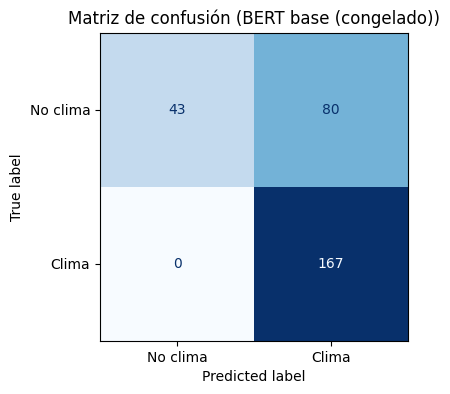

In [66]:
label_names = ['No clima', 'Clima']

y_true_base, y_pred_base, pred_base = evaluate_with_reports(
    trainer=trainer,
    dataset_split=tokenized_dataset['test'],
    split_name='BERT base (congelado)',
    label_names=label_names
)

**Evaluación en el conjunto de prueba**

- La accuracy de 70.3% muestra que el modelo base supera claramente el azar y captura información relevante del corpus.

- No obstante, las métricas por clase indican que este rendimiento global oculta un comportamiento desbalanceado: el modelo identifica mejor la clase "clima" que la clase "no clima".

- Por tanto, este enfoque funciona como una línea base útil, pero todavía presenta limitaciones importantes en equilibrio entre clases y capacidad de generalización fina.

In [67]:
predictions = trainer.predict(tokenized_dataset['test'])

In [68]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

Dataset({
    features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'token_type_ids', 'attention_mask', 'label', 'prediction_label', 'prediction'],
    num_rows: 290
})

Revisamos las etiquetas reales vs las predichas

In [69]:
columns = ['question', 'answer',  'prediction']
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,question,answer,prediction
0,Para la cartera de hipotecas residenciales de ...,1,1
1,"el secretario primero de la mesa del senado, e...",0,0
2,el coronel de la guardia civil diego pérez de ...,0,0
3,"Taylor Swift y Travis Kelce se dan la mano, co...",0,1
4,El riesgo de negocio es el riesgo derivado de ...,1,1
5,Proyectos con impactos sociales o medioambient...,1,1
6,sobre las 12 00 horas ha sido detenido en geta...,0,0
7,"La columnista invitada Jeanell English, ex jef...",0,0
8,Operaciones y emisiones de gases de efecto inv...,1,1
9,ha ocurrido en las palmas de gran canaria. un ...,0,1


Revisamos dónde el modelo no acertó en la predicción

In [70]:
errors = df[df['answer'] != df['prediction']]
errors.head(15)

,question,answer,prediction
3,"Taylor Swift y Travis Kelce se dan la mano, co...",0,1
9,ha ocurrido en las palmas de gran canaria. un ...,0,1
11,Los reporteros del Times @villarrealy y @Mered...,0,1
15,el que fuera consejero delegado y miembro del ...,0,1
16,La mayoría de los encuestados en una nueva enc...,0,1
19,El Grupo está expuesto a múltiples riesgos rel...,0,1
20,Un nuevo estudio encontró evidencia de que la ...,0,1
28,La determinación de la Compañía de crear oport...,0,1
33,Ladrones atacan una cripta centenaria en Color...,0,1
34,Las estrategias de inversión cuantitativa se c...,0,1


# 5.1. Definición del modelo BERTIN ROBERTA

Ahora emplearemos el modelo bertin-project/bertin-roberta-base-spanish, basado en la arquitectura RoBERTa, el cual ha sido entrenado previamente sobre grandes volúmenes de texto en español.

A diferencia de los modelos basados en BERT tradicionales, RoBERTa incorpora mejoras en el proceso de entrenamiento, como una optimización en el uso de datos, eliminación de ciertas restricciones en el preentrenamiento y un ajuste más robusto de los hiperparámetros, lo que permite obtener representaciones lingüísticas más ricas y precisas.

Usar mismo tokenizador con el que fue entrenado el modelo

In [99]:
model_bertin = "bertin-project/bertin-roberta-base-spanish"

tokenizer_bertin = AutoTokenizer.from_pretrained(model_bertin)

In [100]:
tokenizer_bertin.pad_token = '[PAD]'
tokenizer_bertin("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()

['<s>',
 'hola',
 'Ġmundo',
 '!!',
 '</s>',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Podemos observar una diferencia en la tokenizacion

In [101]:
tokenizer_bertin.vocab_size

50262

A diferencia de modelos como dccuchile/bert-base-spanish-wwm-cased, que cuentan con un vocabulario cercano a 30.000 tokens, bertin-project/bertin-roberta-base-spanish utiliza un vocabulario más amplio de 50.262 tokens, lo que permite una mejor representación del lenguaje al reducir la fragmentación en subpalabras, aunque con un ligero incremento en el costo computacional.

In [102]:
tokenizer_bertin.model_max_length

512

In [103]:
tokenizer_bertin.model_input_names

['input_ids', 'attention_mask']

In [104]:
tokens_bertin = sorted(tokenizer_bertin.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {tokenizer_bertin.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{tokenizer_bertin.convert_tokens_to_string([t])}" for t, _ in tokens_bertin[:15]])
print("15 tokens de en medio:")
print([f"{tokenizer_bertin.convert_tokens_to_string([t])}" for t, _ in tokens_bertin[20000:20020]])
print("Últimos 15 tokens:")
print([f"{tokenizer_bertin.convert_tokens_to_string([t])}" for t, _ in tokens_bertin[-15:]])

Vocabulario: 50262 tokens
Primeros 15 tokens:
['<s>', '<pad>', '</s>', '<unk>', '<mask>', '[UNUSED-0]', '[UNUSED-1]', '[UNUSED-2]', '[UNUSED-3]', '[UNUSED-4]', '[UNUSED-5]', '[UNUSED-6]', '[UNUSED-7]', '[UNUSED-8]', '[UNUSED-9]']
15 tokens de en medio:
[' encuestados', ' drás', 'UGT', ' marx', ' Especi', ' retira', ' VIS', ' STORE', ' fascismo', 'ADORES', ' amuebl', ' inco', 'anca', ' Moder', 'Vox', ' cesta', ' protestar', 'gg', ' Barre', ' gestionado']
Últimos 15 tokens:
[' 720', ' enfrentaba', ' camilla', ' posar', ' Écija', 'ember', ' refinado', ' integrador', '280', ' expulsada', 'gls', ' Carrusel', 'estidos', ' Mediterránea', ' Auditoría']


Definimos el modelo BERTIN pre entrenado

In [105]:
model_bertin = AutoModelForSequenceClassification.from_pretrained(model_bertin, num_labels=len(category2id)).to(device)

# Congelamos los pesos del modelo base para usarlo como featurizer solamente.
for param in model_bertin.base_model.parameters():
    param.requires_grad = False


input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model_bertin, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1147.51it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]             
RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
RobertaForSequenceClassification                             [1, 10]                   [1, 2]                    --                        Partial
├─RobertaModel: 1-1                                          [1, 10]                   [1, 10, 768]              --                        False
│    └─RobertaEmbeddings: 2-1                                --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (38,601,216)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (768)                     False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (394,752)  

In [106]:
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model_bertin(**inputs)
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 2])}


In [79]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.1999, -0.0873]]), hidden_states=None, attentions=None)

In [107]:
model_bertin.classifier

RobertaClassificationHead(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (out_proj): Linear(in_features=768, out_features=2, bias=True)
)

Creamos los datasets con el nuevo tokenizador

In [108]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer_bertin(examples['question'], max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function

def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer_bertin(batch['question'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize

def category_names_2_ids(batch):
    batch['label'] = category2id[batch['answer']]
    return batch

In [109]:
tokenized_bertin_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)
tokenized_bertin_dataset = tokenized_bertin_dataset.map(category_names_2_ids)
tokenized_bertin_dataset

Map: 100%|██████████| 290/290 [00:00<00:00, 8510.34 examples/s]


DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'attention_mask', 'label'],
        num_rows: 2320
    })
    val: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'attention_mask', 'label'],
        num_rows: 290
    })
    test: Dataset({
        features: ['question', 'answer', 'dominio', 'país_origen', 'idioma', 'registro', 'tarea', 'periodo', 'input_ids', 'attention_mask', 'label'],
        num_rows: 290
    })
})

Definición del proceso de entrenamiento

In [110]:
batch_size = 8 if IN_COLAB else 4
logging_steps = len(tokenized_bertin_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args_bertin = TrainingArguments(
    output_dir='./bertin_preentrenado',
    num_train_epochs=2,
    learning_rate=2e-5,
    lr_scheduler_type='linear',
    optim="adamw_torch",
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='tensorboard'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer_bertin = Trainer(
    model=model_bertin,
    args=training_args_bertin,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_bertin_dataset['train'],
    eval_dataset=tokenized_bertin_dataset['val'],
    processing_class=tokenizer_bertin
)

In [85]:
%%time
trainer_bertin.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.590370,0.572801,0.706897
2,0.553558,0.556768,0.706897


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

CPU times: user 25.2 s, sys: 5.19 s, total: 30.4 s
Wall time: 3min 16s


TrainOutput(global_step=1160, training_loss=0.5719639219086746, metrics={'train_runtime': 195.9131, 'train_samples_per_second': 23.684, 'train_steps_per_second': 5.921, 'total_flos': 1610239658803200.0, 'train_loss': 0.5719639219086746, 'epoch': 2.0})

In [86]:
model_bertin.eval()
trainer_bertin.evaluate(tokenized_bertin_dataset['test'])

{'eval_loss': 0.5716321468353271,
 'eval_accuracy': 0.7034482758620689,
 'eval_runtime': 10.9532,
 'eval_samples_per_second': 26.476,
 'eval_steps_per_second': 6.665,
 'epoch': 2.0}


=== Reporte de clasificación (BERTIN ROBERTA base (congelado)) ===
              precision    recall  f1-score   support

    No clima     1.0000    0.3008    0.4625       123
       Clima     0.6601    1.0000    0.7952       167

    accuracy                         0.7034       290
   macro avg     0.8300    0.6504    0.6289       290
weighted avg     0.8043    0.7034    0.6541       290



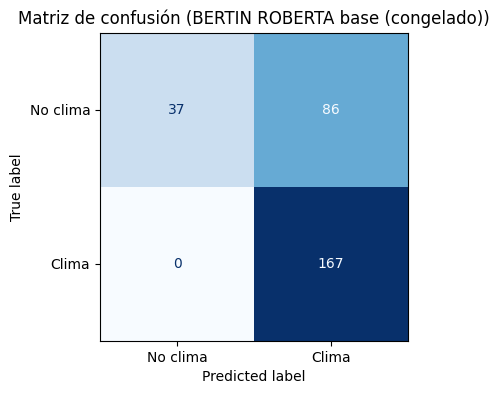

In [87]:
y_true_bertin, y_pred_bertin, pred_bertin= evaluate_with_reports(
    trainer=trainer_bertin,
    dataset_split=tokenized_bertin_dataset['test'],
    split_name='BERTIN ROBERTA base (congelado)',
    label_names=label_names
)

En comparación con el modelo dccuchile/bert-base-spanish-wwm-cased en modo congelado, el modelo bertin-project/bertin-roberta-base-spanish muestra una mejora moderada en el desempeño global. Esto sugiere que el preentrenamiento y el tokenizador de BERTIN aportan representaciones ligeramente más adecuadas para esta tarea.

Sin embargo, la mejora sigue siendo limitada frente al fine-tuning completo. Además, al revisar las métricas por clase, ambos modelos congelados mantienen una tendencia a favorecer la clase "clima", lo que indica que usar embeddings preentrenados sin adaptar el modelo reduce la capacidad para separar correctamente los casos más ambiguos de la clase "no clima".

# 6. Uso de clasificador especializado

Hasta este punto, se ha utilizado la configuración estándar de BertForSequenceClassification, la cual emplea una única capa lineal como clasificador final. Si bien esta aproximación es eficiente, puede resultar limitada para capturar relaciones más complejas en los datos.

Con el objetivo de mejorar el desempeño del modelo, se propone implementar un clasificador personalizado, añadiendo mayor profundidad a la arquitectura mediante múltiples capas densas. En este enfoque, el modelo BERT continúa utilizándose como extractor de características (feature extractor), mientras que la nueva cabeza de clasificación introduce mayor capacidad de aprendizaje no lineal.

Cargamos nuevamente el modelo

In [88]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(category2id)).to(device)

for param in model.base_model.parameters():
    param.requires_grad = False


input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1085.10it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]             
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
cl

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 2]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

Rectificamos el clasificador

In [89]:
model.classifier

Linear(in_features=768, out_features=2, bias=True)

El clasificador propuesto está compuesto por:

- Capa Lineal (768 → 256): reducción de dimensionalidad y extracción de características relevantes

- Layer Normalization: mejora la estabilidad del entrenamiento

- ReLU: introduce no linealidad

- Dropout: reduce el riesgo de sobreajuste

- Capa final (256 → 2): genera los logits para la clasificación binaria

In [90]:
import torch.nn as nn


classifier = nn.Sequential(
    nn.Linear(768, 256),
    nn.LayerNorm(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

# simplemente reemplazamos el clasificador existente por el nuestro:
model.classifier = classifier
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 2]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

In [91]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

In [92]:
%%time

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.470498,0.323077,0.879310
2,0.344271,0.304341,0.868966


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.07it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

CPU times: user 40.3 s, sys: 9.15 s, total: 49.4 s
Wall time: 4min 43s


TrainOutput(global_step=1160, training_loss=0.4073847408952384, metrics={'train_runtime': 282.9443, 'train_samples_per_second': 16.399, 'train_steps_per_second': 4.1, 'total_flos': 1223634113986560.0, 'train_loss': 0.4073847408952384, 'epoch': 2.0})

Tras implementar el clasificador personalizado sobre BERT, se observan mejoras claras en el desempeño del modelo:

- La pérdida de entrenamiento disminuye de 0.53 a 0.40, lo que evidencia una mejor capacidad de ajuste respecto al modelo base congelado.

- La pérdida de validación también se reduce de 0.40 a 0.37, indicando que la nueva cabeza de clasificación extrae mejor la información útil de las representaciones generadas por BERT.

- La accuracy alcanza 82.76%, mostrando que una cabeza más expresiva mejora de forma importante el rendimiento sin necesidad de liberar todavía todos los parámetros del encoder.

In [93]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

{'eval_loss': 0.29897257685661316,
 'eval_accuracy': 0.8586206896551725,
 'eval_runtime': 10.5534,
 'eval_samples_per_second': 27.479,
 'eval_steps_per_second': 6.917,
 'epoch': 2.0}


=== Reporte de clasificación (BERT + clasificador personalizado) ===
              precision    recall  f1-score   support

    No clima     0.9020    0.7480    0.8178       123
       Clima     0.8351    0.9401    0.8845       167

    accuracy                         0.8586       290
   macro avg     0.8685    0.8440    0.8511       290
weighted avg     0.8635    0.8586    0.8562       290



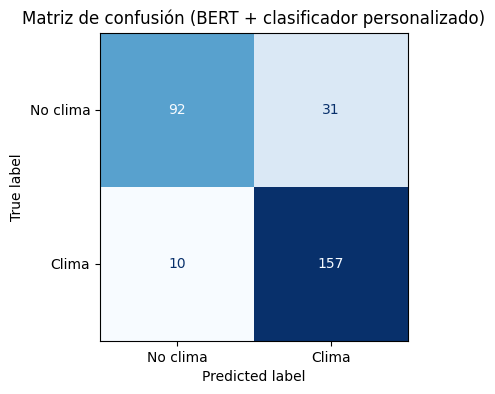

In [94]:
y_true_custom, y_pred_custom, pred_custom = evaluate_with_reports(
    trainer=trainer,
    dataset_split=tokenized_dataset['test'],
    split_name='BERT + clasificador personalizado',
    label_names=label_names
)

- La accuracy de 86.55% evidencia una mejora sustancial frente al modelo base, confirmando que el clasificador personalizado aporta capacidad adicional de discriminación.

- Aun así, el análisis por clase muestra que el modelo sigue favoreciendo más la detección de "clima" que la de "no clima", por lo que el problema de balance no desaparece por completo.

- En consecuencia, este enfoque representa un punto intermedio sólido: mejora claramente al baseline, pero todavía queda por debajo del comportamiento más equilibrado alcanzado con fine-tuning completo.

# 7. Fine-tuning del modelo BERT

En esta etapa se aplica fine-tuning sobre el modelo BERT, lo que implica liberar todas las capas del modelo para que sus parámetros sean actualizados durante el entrenamiento.

A diferencia del enfoque anterior, donde el modelo se utilizaba como extractor de características con pesos congelados, en este caso se permite que toda la arquitectura aprenda de la tarea específica. Esto posibilita un ajuste más profundo de las representaciones internas, adaptándolas al dominio del problema.

Para este proceso, no es necesario modificar la estructura del modelo preentrenado; simplemente se instancia el modelo base y se entrena directamente sobre el dataset, permitiendo que todos sus parámetros participen en la optimización.


In [95]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(category2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1576.58it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]              
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
c

In [96]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.200387,0.104699,0.979310
2,0.057908,0.126941,0.975862


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.52it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

CPU times: user 1min 31s, sys: 26.1 s, total: 1min 57s
Wall time: 10min 38s


TrainOutput(global_step=1160, training_loss=0.1291473158474626, metrics={'train_runtime': 638.4994, 'train_samples_per_second': 7.267, 'train_steps_per_second': 1.817, 'total_flos': 1220835296870400.0, 'train_loss': 0.1291473158474626, 'epoch': 2.0})

Tras aplicar fine-tuning sobre el modelo BERT, se obtienen los resultados más sólidos de este análisis:

- La pérdida de entrenamiento disminuye significativamente de 0.187 a 0.062, evidenciando un aprendizaje mucho más profundo que en los enfoques con encoder congelado.

- La pérdida de validación se mantiene en valores muy bajos (~0.07), lo que sugiere que el modelo logra adaptarse al dominio sin perder estabilidad en la generalización.

- La accuracy alcanza 98.27%, confirmando que permitir el ajuste de todos los parámetros produce la mejora más importante en esta tarea.

In [111]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

{'eval_loss': 0.1264818161725998,
 'eval_accuracy': 0.9758620689655172,
 'eval_runtime': 15.1661,
 'eval_samples_per_second': 19.122,
 'eval_steps_per_second': 4.813,
 'epoch': 2.0}


=== Reporte de clasificación (BERT fine-tuning completo) ===
              precision    recall  f1-score   support

    No clima     0.9754    0.9675    0.9714       123
       Clima     0.9762    0.9820    0.9791       167

    accuracy                         0.9759       290
   macro avg     0.9758    0.9748    0.9753       290
weighted avg     0.9759    0.9759    0.9758       290



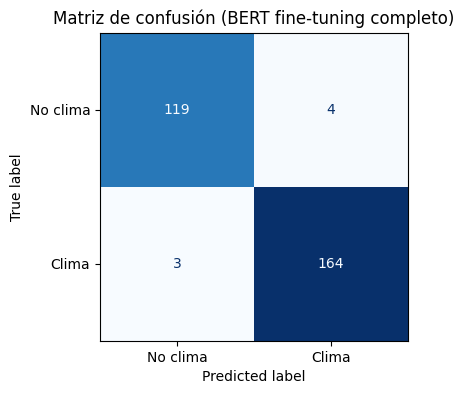

In [112]:
y_true_ft, y_pred_ft, pred_ft = evaluate_with_reports(
    trainer=trainer,
    dataset_split=tokenized_dataset['test'],
    split_name='BERT fine-tuning completo',
    label_names=label_names
)

- La accuracy cercana al 98% confirma un desempeño sobresaliente en datos no vistos.

- A diferencia de los modelos congelados, aquí las métricas por clase son mucho más equilibradas, lo que indica que el modelo no solo acierta más, sino que también discrimina mejor entre textos relacionados y no relacionados con cambio climático.

- La consistencia entre validación y prueba refuerza la idea de que el fine-tuning completo es el enfoque más robusto y generalizable dentro de los experimentos realizados.

# Comparación consolidada de modelos

Esta tabla resume las métricas más importantes para comparar los tres enfoques evaluados:

- Accuracy

- Balanced Accuracy

- Macro F1

- Recall por clase (No clima / Clima)

- Precision por clase (No clima / Clima)


In [113]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, precision_score
import pandas as pd

results_summary = []

model_predictions = {
    'BERT base (congelado)': (y_true_base, y_pred_base),
    'BERTIN ROBERTA base (congelado)': (y_true_bertin, y_pred_bertin),
    'BERT + clasificador personalizado': (y_true_custom, y_pred_custom),
    'BERT fine-tuning completo': (y_true_ft, y_pred_ft)
}

for model_name, (y_true, y_pred) in model_predictions.items():
    results_summary.append({
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall No clima (0)': recall_score(y_true, y_pred, pos_label=0, average='binary', zero_division=0),
        'Recall Clima (1)': recall_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0),
        'Precision No clima (0)': precision_score(y_true, y_pred, pos_label=0, average='binary', zero_division=0),
        'Precision Clima (1)': precision_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0)
    })

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by='Macro F1', ascending=False).reset_index(drop=True)

numeric_cols = [
    'Accuracy', 'Balanced Accuracy', 'Macro F1',
    'Recall No clima (0)', 'Recall Clima (1)',
    'Precision No clima (0)', 'Precision Clima (1)'
]
results_df[numeric_cols] = results_df[numeric_cols].round(4)

results_df

,Modelo,Accuracy,Balanced Accuracy,Macro F1,Recall No clima (0),Recall Clima (1),Precision No clima (0),Precision Clima (1)
0,BERT fine-tuning completo,0.9759,0.9748,0.9753,0.9675,0.9820,0.9754,0.9762
1,BERT + clasificador personalizado,0.8586,0.8440,0.8511,0.7480,0.9401,0.9020,0.8351
2,BERT base (congelado),0.7241,0.6748,0.6624,0.3496,1.0000,1.0000,0.6761
3,BERTIN ROBERTA base (congelado),0.7034,0.6504,0.6289,0.3008,1.0000,1.0000,0.6601


Los resultados muestran que el modelo dccuchile/bert-base-spanish-wwm-cased con fine-tuning completo logra el mejor desempeño global, alcanzando métricas muy altas y balanceadas en ambas clases. Esto sugiere que el ajuste fino no solo mejora la accuracy, sino también la capacidad del modelo para discriminar entre ejemplos positivos y negativos de forma más estable.

En contraste, los modelos con BERT congelado y bertin-project/bertin-roberta-base-spanish congelado presentan un rendimiento considerablemente inferior, con un fuerte sesgo hacia la clase "clima", evidenciado por recalls muy altos para esa clase y mucho más bajos para la clase "no clima". Esto indica que, sin ajuste fino, las representaciones preentrenadas capturan parte del vocabulario temático, pero no adaptan suficientemente el contexto para resolver ejemplos fronterizos.

El modelo con clasificador personalizado mejora frente a los modelos congelados, pero aún mantiene cierto desbalance entre clases. Esto sugiere que enriquecer la cabeza de clasificación ayuda, aunque el mayor salto de rendimiento proviene de permitir que todo el modelo ajuste sus representaciones internas a la tarea específica.

En conjunto, se concluye que el fine-tuning completo es fundamental para obtener el mejor desempeño y el mejor equilibrio entre clases, mientras que los modelos congelados funcionan como un baseline útil, pero limitado.

# 8. Conclusiones

En este notebook se evaluaron cuatro enfoques para la clasificación de textos relacionados con cambio climático usando el dataset somosnlp/spa_climate_detection: BERT congelado, BERTIN RoBERTa congelado, BERT con clasificador personalizado y BERT con fine-tuning completo.

### Principales hallazgos

- Los modelos congelados funcionan como una línea base razonable, pero muestran limitaciones claras en capacidad de discriminación.
- BERTIN RoBERTa supera levemente a BERT en modo congelado, lo que sugiere una ventaja del preentrenamiento y del tokenizador para textos en español.
- Añadir un clasificador más expresivo mejora el rendimiento respecto a los modelos congelados, pero no elimina por completo el sesgo entre clases.
- El fine-tuning completo obtiene el mejor desempeño global y el mejor equilibrio entre la clase "clima" y la clase "no clima".

### Interpretación de resultados

El análisis de métricas por clase muestra que los modelos congelados tienden a favorecer la clase positiva, logrando recalls muy altos para "clima" pero bastante más bajos para "no clima". Esto indica que, aunque los embeddings preentrenados capturan bien el vocabulario temático, no son suficientes por sí solos para resolver adecuadamente los casos más ambiguos.

El clasificador personalizado reduce parte de esta limitación al introducir una cabeza no lineal más potente. Sin embargo, el principal salto de calidad aparece cuando se permite que todo el modelo ajuste sus representaciones al dominio específico. En ese escenario, BERT no solo mejora la accuracy, sino también el balance entre clases, lo que fortalece la capacidad de generalización del sistema.

### Conclusión final

Los resultados demuestran que, para esta tarea, el factor más importante no es únicamente elegir un buen modelo preentrenado, sino permitir que dicho modelo se adapte a la tarea mediante fine-tuning. Por ello, el enfoque más sólido en este notebook es BERT con fine-tuning completo, mientras que los modelos congelados y el clasificador personalizado sirven como comparaciones útiles para evidenciar cómo cambia el rendimiento al aumentar el nivel de adaptación del modelo.

# 9. Referencias

@article{BERTIN,
    author = {Javier De la Rosa y Eduardo G. Ponferrada y Manu Romero y Paulo Villegas y Pablo González de Prado Salas y María Grandury},
    title = {BERTIN: Efficient Pre-Training of a Spanish Language Model using Perplexity Sampling},
    journal = {Procesamiento del Lenguaje Natural},
    volume = {68},
    number = {0},
    year = {2022},
    keywords = {},
    abstract = {The pre-training of large language models usually requires massive amounts of resources, both in terms of computation and data. Frequently used web sources such as Common Crawl might contain enough noise to make this pretraining sub-optimal. In this work, we experiment with different sampling methods from the Spanish version of mC4, and present a novel data-centric technique which we name perplexity sampling that enables the pre-training of language models in roughly half the amount of steps and using one fifth of the data. The resulting models are comparable to the current state-of-the-art, and even achieve better results for certain tasks. Our work is proof of the versatility of Transformers, and paves the way for small teams to train their models on a limited budget.},
    issn = {1989-7553},
    url = {http://journal.sepln.org/sepln/ojs/ojs/index.php/pln/article/view/6403},
    pages = {13--23}
}
